<a href="https://www.kaggle.com/code/naufalmaulanamaliksr/lr-svm-for-customer-transaction-value-prediction?scriptVersionId=346402608" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Linear Regression, Support Vector Machine For Customer Transaction Value Prediction

## Impor Librari Pandas, Numpy, OS, Matplotlib, Seaborn, Scikit Learn, Warnings, Collections, Joblib, dan Datetime

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl
import warnings
import collections
import joblib

from datetime import datetime as dttm

warnings.filterwarnings('ignore')

filepath = None

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filepath is None:
            filepath = os.path.join(dirname, filename)

dataframe = pd.read_csv(filepath)
shape_0, shape_1 = dataframe.shape
columns = dataframe.columns
categorical_columns = dataframe.select_dtypes(include=[object]).columns
numerical_columns = dataframe.select_dtypes(exclude=[object]).columns

## Imputasi Nilai _Missing Values_ Pada Kolom `Promotion` Dengan Nilai `Unknown Promotion`

In [2]:
fillna_promotion = dataframe.Promotion.fillna("Unknown Promotion")
dataframe.Promotion = fillna_promotion
display(dataframe.head())

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,time_of_day,Customer_Category,Season,Promotion,Member
0,1000000000,2022-06-20,Michael Young,"['Tea', 'Swim Cap', 'Sandals', 'Slippers']",4,38.27,Cash,Eduardoberg,13:24:15,Adult (30-49),Winter,Discount on Selected Items,No
1,1000000001,2023-07-23,Lindsay Simmons,"['Band-Aids', 'Lighter Fluid', 'Beef']",3,21.63,Cash,Mariaton,09:56:29,Young Adult (20-29),Winter,Discount on Selected Items,No
2,1000000002,2021-10-28,Mrs. Jessica Reed,"['Onion Powder', 'Dish Soap', 'Salt', 'Aluminu...",5,43.19,Mobile Payment,Strongview,18:29:29,Adult (30-49),Summer,BOGO (Buy One Get One),No
3,1000000003,2022-11-04,Spencer Rowe,"['Apples', 'Tomato Sauce', 'Tape', 'Bug Spray'...",8,93.44,Credit Card,North Jeremiah,17:02:19,Senior (65+),Fall,Discount on Selected Items,No
4,1000000004,2023-09-29,Brenda Jones,"['Bug Spray', 'Bath Mat', 'Multi-Surface Clean...",7,55.56,Debit Card,Sandramouth,19:08:32,Adult (30-49),Fall,BOGO (Buy One Get One),Yes


## _Feature Engineering_ Khusus Kolom `Transaction_ID`, `Date`, dan `time_of_day`

In [3]:
dataframe.Transaction_ID = dataframe.Transaction_ID.astype(str)
dataframe["Datetime"] = dataframe.Date + " " + dataframe.time_of_day
dataframe = dataframe.sort_values("Datetime")
dataframe = dataframe.reset_index(drop=True).drop(columns='Transaction_ID')
datetime_series = dataframe.Datetime
dataframe = dataframe.drop(columns=["Date", "Datetime"], axis=1)
dataframe.insert(0, "Transaction_Datetime", datetime_series)
dataframe.head()

,Transaction_Datetime,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,time_of_day,Customer_Category,Season,Promotion,Member
0,2020-01-01 02:20:33,Jonathan Rollins,"['Nail Clippers', 'Bath Salts', 'Pasta', 'Popc...",6,60.07,Cash,Walshfort,02:20:33,Young Adult (20-29),Spring,Discount on Selected Items,Yes
1,2020-01-01 02:21:50,Betty Robinson,"['Sunglasses', 'Exercise Ball', 'Dish Soap']",3,34.90,Debit Card,North Tara,02:21:50,Teenager (13-19),Spring,BOGO (Buy One Get One),Yes
2,2020-01-01 02:29:03,Terrance Garrison,"['Frozen Vegetables', 'Shoes', 'Calculator', '...",4,34.44,Cash,West Clifford,02:29:03,Young Adult (20-29),Winter,BOGO (Buy One Get One),Yes
3,2020-01-01 04:11:50,Robert Davis,"['Soy Sauce', 'Peanut Butter', 'Sweater', 'Sod...",7,86.90,Debit Card,Martinezfurt,04:11:50,Young Adult (20-29),Winter,Unknown Promotion,Yes
4,2020-01-01 08:37:23,Jeffrey Hawkins,"['Salt', 'Shelving', 'Soy Sauce', 'Nail Polish...",6,62.57,Mobile Payment,Benjaminview,08:37:23,Adult (30-49),Spring,Unknown Promotion,Yes


In [4]:
timestamp_ = dataframe.time_of_day.str.split(":", expand=True)
timestamp_.columns = ['hour', 'minute', 'second']
timestamp_.hour = timestamp_.hour.astype(int)

def _get_time_classes_(x):
    if 0 <= x <= 3:
        return 'Early Morning'
    elif 4 <= x <= 9:
        return 'Morning'
    elif 10 <= x <= 15:
        return 'Midday'
    elif 16 <= x <= 18:
        return 'Afternoon'
    elif 19 <= x <= 21:
        return 'Evening'
    else:
        return 'Late Night'

dataframe['TimeClass'] = timestamp_.hour.apply(_get_time_classes_)
dataframe = dataframe.drop(columns='time_of_day')

## _Feature Engineering_ khusus Kolom `Product`

In [5]:
customer_carts = dataframe.Product.str.replace("[", "").str.replace("]", "")
customer_carts = customer_carts.str.split(", ")

mlb = skl.preprocessing.MultiLabelBinarizer()

customer_carts_mlb = mlb.fit_transform(customer_carts)
products = ["Buy_" + class_.replace("'", "") for class_ in mlb.classes_]

customer_carts_df = pd.DataFrame(customer_carts_mlb, columns=products)

# binary_bool = lambda x: True if x == 1 else False

dataframe_ = dataframe.drop(columns="Product")

for k in range(1, len(products) + 1):
    bool_ = customer_carts_df[products[k-1]]
    dataframe_.insert(k-1, products[k-1], bool_)

dataframe_.head()

,Buy_Air Freshener,Buy_Allergy Medicine,Buy_Almonds,Buy_Aluminum Foil,Buy_Apples,Buy_Backpack,Buy_Bagels,Buy_Baking Powder,Buy_Baking Soda,Buy_Bananas,...,Customer_Name,Total_Items,Total_Cost,Payment_Method,City,Customer_Category,Season,Promotion,Member,TimeClass
0,0,0,0,0,0,0,0,0,0,0,...,Jonathan Rollins,6,60.07,Cash,Walshfort,Young Adult (20-29),Spring,Discount on Selected Items,Yes,Early Morning
1,0,0,0,0,0,0,0,0,0,0,...,Betty Robinson,3,34.90,Debit Card,North Tara,Teenager (13-19),Spring,BOGO (Buy One Get One),Yes,Early Morning
2,0,0,0,0,0,0,0,0,0,0,...,Terrance Garrison,4,34.44,Cash,West Clifford,Young Adult (20-29),Winter,BOGO (Buy One Get One),Yes,Early Morning
3,0,0,0,0,0,0,0,0,0,0,...,Robert Davis,7,86.90,Debit Card,Martinezfurt,Young Adult (20-29),Winter,Unknown Promotion,Yes,Morning
4,0,0,0,0,0,0,0,0,0,0,...,Jeffrey Hawkins,6,62.57,Mobile Payment,Benjaminview,Adult (30-49),Spring,Unknown Promotion,Yes,Morning


## _Data Splitting_ dengan Rasio _Training Data_ dan _Testing Data_ 80:20

In [6]:
X = dataframe_.drop(columns=["Transaction_Datetime", "Total_Cost", "City"], axis=1)
y = dataframe_["Total_Cost"]

tts = skl.model_selection.train_test_split

X_train, X_test, y_train, y_test = tts(X, y, test_size=0.2, shuffle=False)

## _Feature Engineering_ khusus kolom `Customer_Name`

In [7]:
X_train_loyalty = X_train.groupby("Customer_Name").size().reset_index()
X_train_loyalty = X_train_loyalty.rename(columns={0: 'Transaction_Counts'})
X_train_loyalty.sort_values("Transaction_Counts", ascending=False).head()

,Customer_Name,Transaction_Counts
2614,Christopher Smith,7
9165,Michael Brown,6
5255,James Rodriguez,6
8827,Matthew Jones,6
6536,Joseph Jones,6


In [8]:
def _loyalty_classes_(x):
    if 1 <= x <= 2:
        return 'Regular'
    elif 3 <= x <= 4:
        return 'Silver'
    elif 5 <= x <= 6:
        return 'Gold'
    else:
        return 'Platinum'

loyalty_level = X_train_loyalty["Transaction_Counts"].apply(_loyalty_classes_)
X_train_loyalty["Loyalty_Level"] = loyalty_level

customers_ = X_train_loyalty.Customer_Name.values.tolist()
levels_ = X_train_loyalty.Loyalty_Level.values.tolist()

function_ = lambda x: [v for k, v in zip(customers_, levels_) if k == x][0]

X_train["Loyalty_Level"] = X_train["Customer_Name"].apply(function_)
X_train = X_train.drop(columns="Customer_Name")
X_train.head()

,Buy_Air Freshener,Buy_Allergy Medicine,Buy_Almonds,Buy_Aluminum Foil,Buy_Apples,Buy_Backpack,Buy_Bagels,Buy_Baking Powder,Buy_Baking Soda,Buy_Bananas,...,Buy_Yogurt,Buy_Ziploc Bags,Total_Items,Payment_Method,Customer_Category,Season,Promotion,Member,TimeClass,Loyalty_Level
0,0,0,0,0,0,0,0,0,0,0,...,0,0,6,Cash,Young Adult (20-29),Spring,Discount on Selected Items,Yes,Early Morning,Regular
1,0,0,0,0,0,0,0,0,0,0,...,0,0,3,Debit Card,Teenager (13-19),Spring,BOGO (Buy One Get One),Yes,Early Morning,Regular
2,0,0,0,0,0,0,0,0,0,0,...,0,0,4,Cash,Young Adult (20-29),Winter,BOGO (Buy One Get One),Yes,Early Morning,Regular
3,0,0,0,0,0,0,0,0,0,0,...,0,0,7,Debit Card,Young Adult (20-29),Winter,Unknown Promotion,Yes,Morning,Regular
4,0,0,0,0,0,0,0,0,0,0,...,0,0,6,Mobile Payment,Adult (30-49),Spring,Unknown Promotion,Yes,Morning,Regular


## Visualisasi Data Jumlah Pelanggan Berdasarkan Segmentasi Kolom `Loyalty_Level`

<Axes: xlabel='Customers', ylabel='Loyalty_Level'>

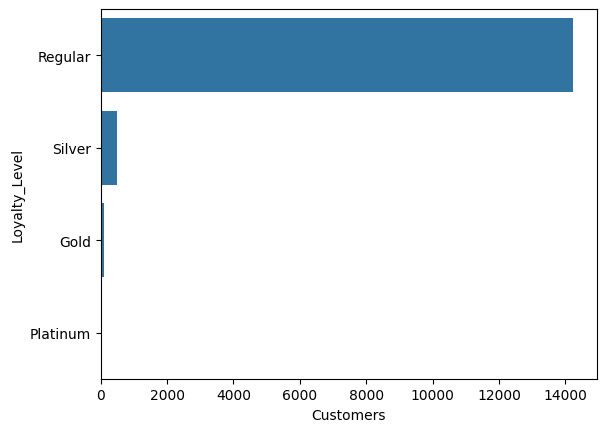

In [9]:
X_train_loyalty_level = X_train.groupby("Loyalty_Level").size().reset_index()
X_train_loyalty_level = X_train_loyalty_level.rename(columns={0:"Customers"})
sorted_data = X_train_loyalty_level.sort_values("Customers", ascending=False)

sns.barplot(sorted_data, y="Loyalty_Level", x="Customers")

## Visualisasi Data Jumlah Barang Belanjaan Berdasarkan Kolom `Total_Items`

<Axes: ylabel='Total_Items'>

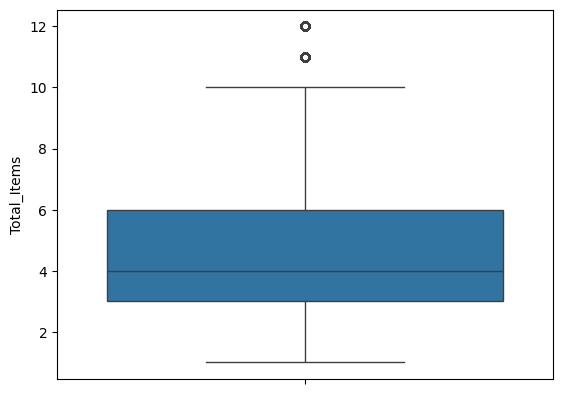

In [10]:
sns.boxplot(X_train, y="Total_Items")

## Visualisasi Data Jumlah Barang Belanjaan Berdasarkan Transformasi Logaritmik Kolom `Total_Items`

<Axes: ylabel='Total_Items'>

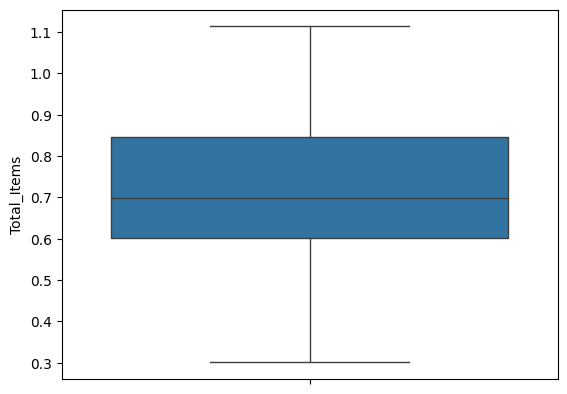

In [11]:
sns.boxplot(np.log10(X_train.Total_Items + 1))

## _Feature Engineering_ khusus Kolom `Total_Items`

In [12]:
log10_transformed_added_total_items = round(np.log10(X_train.Total_Items + 1), 2)

X_train["Log10_Transformed_Total_Items"] = log10_transformed_added_total_items
X_train = X_train.drop(["Total_Items"], axis=1)
X_train.head()

,Buy_Air Freshener,Buy_Allergy Medicine,Buy_Almonds,Buy_Aluminum Foil,Buy_Apples,Buy_Backpack,Buy_Bagels,Buy_Baking Powder,Buy_Baking Soda,Buy_Bananas,...,Buy_Yogurt,Buy_Ziploc Bags,Payment_Method,Customer_Category,Season,Promotion,Member,TimeClass,Loyalty_Level,Log10_Transformed_Total_Items
0,0,0,0,0,0,0,0,0,0,0,...,0,0,Cash,Young Adult (20-29),Spring,Discount on Selected Items,Yes,Early Morning,Regular,0.85
1,0,0,0,0,0,0,0,0,0,0,...,0,0,Debit Card,Teenager (13-19),Spring,BOGO (Buy One Get One),Yes,Early Morning,Regular,0.60
2,0,0,0,0,0,0,0,0,0,0,...,0,0,Cash,Young Adult (20-29),Winter,BOGO (Buy One Get One),Yes,Early Morning,Regular,0.70
3,0,0,0,0,0,0,0,0,0,0,...,0,0,Debit Card,Young Adult (20-29),Winter,Unknown Promotion,Yes,Morning,Regular,0.90
4,0,0,0,0,0,0,0,0,0,0,...,0,0,Mobile Payment,Adult (30-49),Spring,Unknown Promotion,Yes,Morning,Regular,0.85


## Visualisasi Data Jumlah Transaksi Berdasarkan Kolom `Payment_Method`

<Axes: xlabel='Customers', ylabel='Payment_Method'>

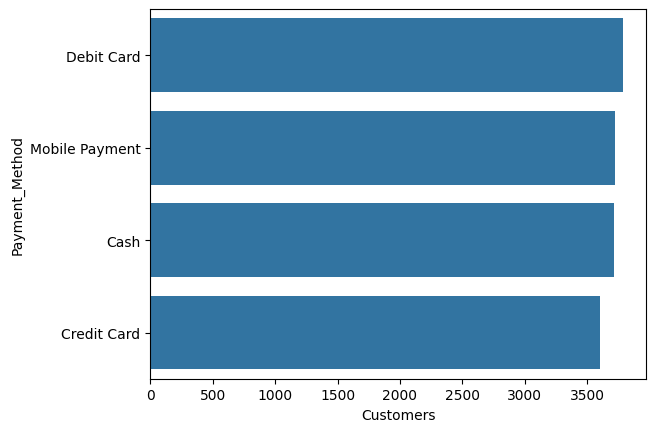

In [13]:
X_train_payment_method = X_train.groupby("Payment_Method").size().reset_index()
X_train_payment_method = X_train_payment_method.rename(columns={0:"Customers"})
sorted_data = X_train_payment_method.sort_values("Customers", ascending=False)

sns.barplot(sorted_data, y="Payment_Method", x="Customers")

## Visualisasi Data Jumlah Transaksi Berdasarkan Kolom `Customer_Category`

<Axes: xlabel='Customers', ylabel='Customer_Category'>

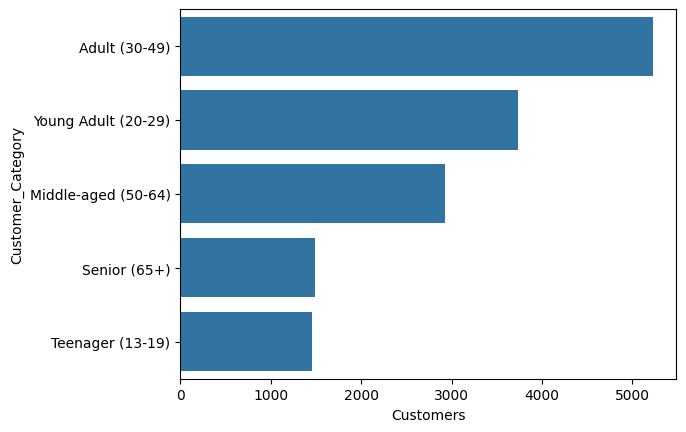

In [14]:
X_train_customer = X_train.groupby("Customer_Category").size().reset_index()
X_train_customer = X_train_customer.rename(columns={0:"Customers"})
sorted_data = X_train_customer.sort_values("Customers", ascending=False)

sns.barplot(sorted_data[:25], y="Customer_Category", x="Customers")

## Visualisasi Data Jumlah Transaksi Berdasarkan Kolom `Season`

<Axes: xlabel='Customers', ylabel='Season'>

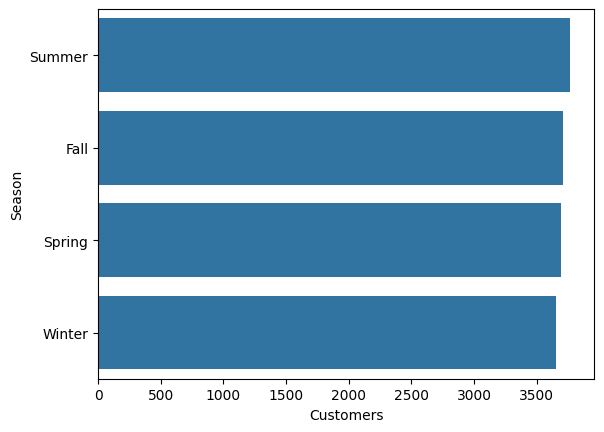

In [15]:
X_train_season = X_train.groupby("Season").size().reset_index()
X_train_season = X_train_season.rename(columns={0:"Customers"})
sorted_data = X_train_season.sort_values("Customers", ascending=False)

sns.barplot(sorted_data[:25], y="Season", x="Customers")

## Visualisasi Data Jumlah Transaksi Berdasarkan Kolom `Promotion`

<Axes: xlabel='Customers', ylabel='Promotion'>

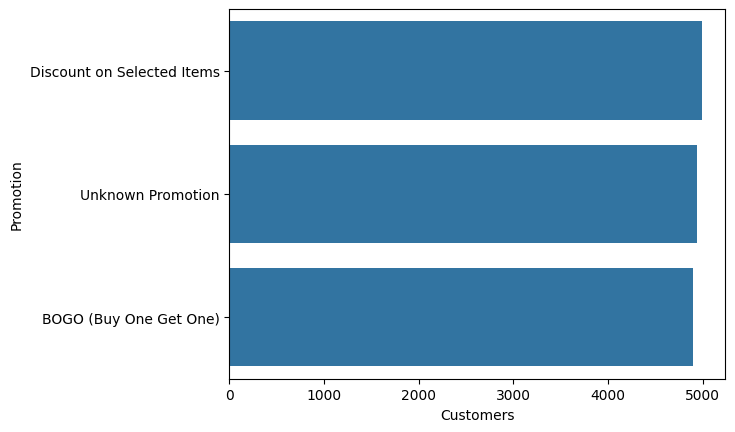

In [16]:
X_train_promotion = X_train.groupby("Promotion").size().reset_index()
X_train_promotion = X_train_promotion.rename(columns={0:"Customers"})
sorted_data = X_train_promotion.sort_values("Customers", ascending=False)

sns.barplot(sorted_data[:25], y="Promotion", x="Customers")

## Visualisasi Data Jumlah Transaksi Berdasarkan Kolom `Member`

<Axes: xlabel='Customers', ylabel='Member'>

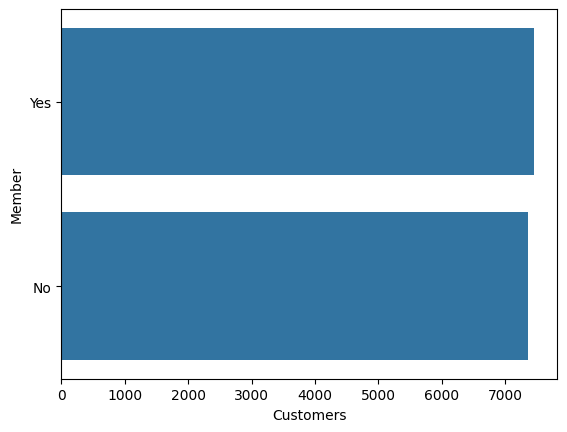

In [17]:
X_train_member = X_train.groupby("Member").size().reset_index()
X_train_member = X_train_member.rename(columns={0:"Customers"})
sorted_data = X_train_member.sort_values("Customers", ascending=False)

sns.barplot(sorted_data[:25], y="Member", x="Customers")

## Visualisasi Data Jumlah Transaksi Berdasarkan Kolom `TimeClass`

<Axes: xlabel='Customers', ylabel='TimeClass'>

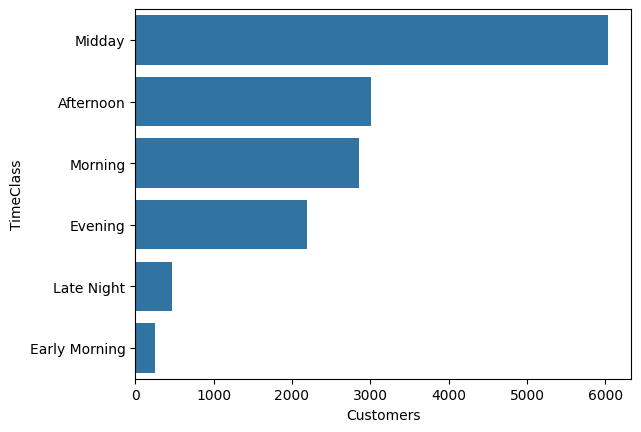

In [18]:
X_train_timeclass = X_train.groupby("TimeClass").size().reset_index()
X_train_timeclass = X_train_timeclass.rename(columns={0:"Customers"})
sorted_data = X_train_timeclass.sort_values("Customers", ascending=False)

sns.barplot(sorted_data[:25], y="TimeClass", x="Customers")

## _Feature Engineering_ khusus Kolom `Customer_Name` (Testing Data)

In [19]:
X_test_loyalty = X_test.groupby("Customer_Name").size().reset_index()
X_test_loyalty = X_test_loyalty.rename(columns={0: 'Transaction_Counts'})
X_test_loyalty.sort_values("Transaction_Counts", ascending=False).head()

,Customer_Name,Transaction_Counts
2526,Michael Smith,4
65,Alexander Williams,3
2937,Robert Smith,3
2552,Michele Torres,3
1443,Jason Parker,3


In [20]:
loyalty_level = X_test_loyalty["Transaction_Counts"].apply(_loyalty_classes_)
X_test_loyalty["Loyalty_Level"] = loyalty_level

customers_ = X_test_loyalty.Customer_Name.values.tolist()
levels_ = X_test_loyalty.Loyalty_Level.values.tolist()

function_ = lambda x: [v for k, v in zip(customers_, levels_) if k == x][0]

X_test["Loyalty_Level"] = X_test["Customer_Name"].apply(function_)
X_test = X_test.drop(columns="Customer_Name")
X_test.head()

,Buy_Air Freshener,Buy_Allergy Medicine,Buy_Almonds,Buy_Aluminum Foil,Buy_Apples,Buy_Backpack,Buy_Bagels,Buy_Baking Powder,Buy_Baking Soda,Buy_Bananas,...,Buy_Yogurt,Buy_Ziploc Bags,Total_Items,Payment_Method,Customer_Category,Season,Promotion,Member,TimeClass,Loyalty_Level
14824,0,0,0,0,0,0,0,0,0,0,...,0,0,9,Cash,Adult (30-49),Winter,Unknown Promotion,Yes,Midday,Regular
14825,0,0,0,0,0,0,0,0,1,0,...,0,0,7,Debit Card,Young Adult (20-29),Fall,Discount on Selected Items,No,Midday,Regular
14826,0,0,0,0,0,0,0,0,0,0,...,0,0,7,Mobile Payment,Adult (30-49),Spring,BOGO (Buy One Get One),No,Midday,Regular
14827,0,0,0,0,0,0,0,0,0,0,...,0,0,1,Mobile Payment,Young Adult (20-29),Winter,Unknown Promotion,Yes,Midday,Regular
14828,0,0,0,0,0,0,0,0,0,0,...,0,0,5,Mobile Payment,Senior (65+),Summer,Unknown Promotion,Yes,Afternoon,Regular


## Visualisasi Data Jumlah Transaksi Berdasarkan Kolom `Loyalty_Level` (Testing Data)

<Axes: xlabel='Customers', ylabel='Loyalty_Level'>

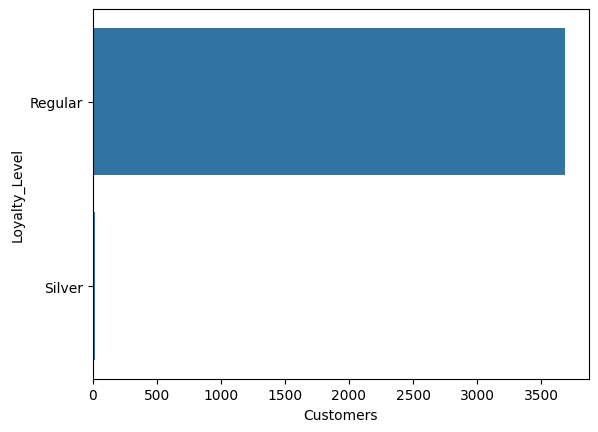

In [21]:
X_test_loyalty_level = X_test.groupby("Loyalty_Level").size().reset_index()
X_test_loyalty_level = X_test_loyalty_level.rename(columns={0:"Customers"})
sorted_data = X_test_loyalty_level.sort_values("Customers", ascending=False)

sns.barplot(sorted_data, y="Loyalty_Level", x="Customers")

## Visualisasi Data Jumlah Barang Belanjaan Berdasarkan Kolom `Total_Items` (Testing Data)

<Axes: ylabel='Total_Items'>

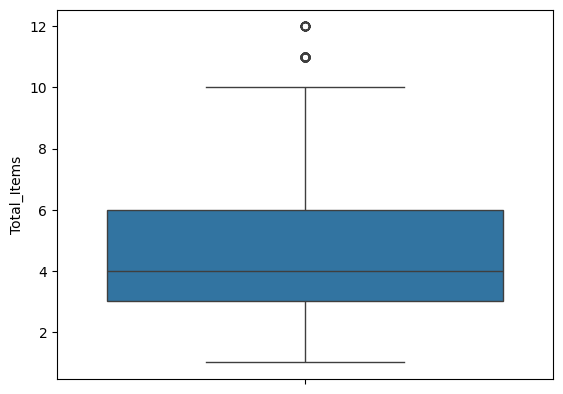

In [22]:
sns.boxplot(X_test.Total_Items)

## _Feature Engineering_ khusus Kolom `Total_Items` (Testing Data)

In [23]:
log10_transformed_added_total_items = round(np.log10(X_test.Total_Items + 1), 2)

X_test["Log10_Transformed_Total_Items"] = log10_transformed_added_total_items
X_test = X_test.drop(["Total_Items"], axis=1)
X_test.head()

,Buy_Air Freshener,Buy_Allergy Medicine,Buy_Almonds,Buy_Aluminum Foil,Buy_Apples,Buy_Backpack,Buy_Bagels,Buy_Baking Powder,Buy_Baking Soda,Buy_Bananas,...,Buy_Yogurt,Buy_Ziploc Bags,Payment_Method,Customer_Category,Season,Promotion,Member,TimeClass,Loyalty_Level,Log10_Transformed_Total_Items
14824,0,0,0,0,0,0,0,0,0,0,...,0,0,Cash,Adult (30-49),Winter,Unknown Promotion,Yes,Midday,Regular,1.00
14825,0,0,0,0,0,0,0,0,1,0,...,0,0,Debit Card,Young Adult (20-29),Fall,Discount on Selected Items,No,Midday,Regular,0.90
14826,0,0,0,0,0,0,0,0,0,0,...,0,0,Mobile Payment,Adult (30-49),Spring,BOGO (Buy One Get One),No,Midday,Regular,0.90
14827,0,0,0,0,0,0,0,0,0,0,...,0,0,Mobile Payment,Young Adult (20-29),Winter,Unknown Promotion,Yes,Midday,Regular,0.30
14828,0,0,0,0,0,0,0,0,0,0,...,0,0,Mobile Payment,Senior (65+),Summer,Unknown Promotion,Yes,Afternoon,Regular,0.78


## Visualisasi Data Jumlah Barang Belanjaan Berdasarkan Kolom `Log10_Transformed_Total_Items` (Testing Data)

<Axes: ylabel='Log10_Transformed_Total_Items'>

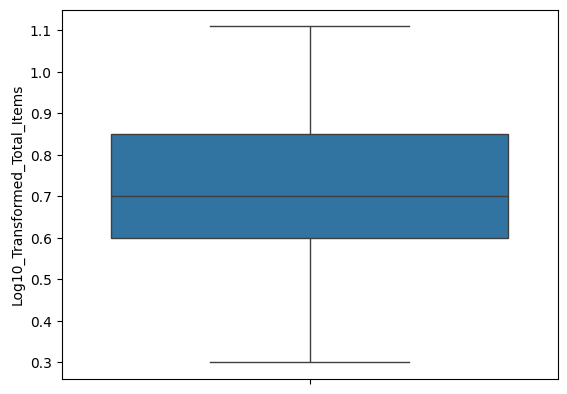

In [24]:
sns.boxplot(X_test.Log10_Transformed_Total_Items)

## Visualisasi Data Jumlah Transaksi Berdasarkan Kolom `Payment_Method` (Testing Data)

<Axes: xlabel='Customers', ylabel='Payment_Method'>

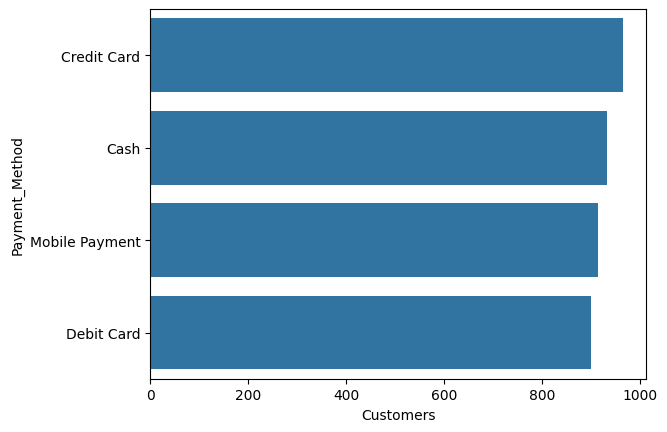

In [25]:
X_test_payment_method = X_test.groupby("Payment_Method").size().reset_index()
X_test_payment_method = X_test_payment_method.rename(columns={0:"Customers"})
sorted_data = X_test_payment_method.sort_values("Customers", ascending=False)

sns.barplot(sorted_data, y="Payment_Method", x="Customers")

## Visualisasi Data Jumlah Transaksi Berdasarkan Kolom `Customer_Category` (Testing Data)

<Axes: xlabel='Customers', ylabel='Customer_Category'>

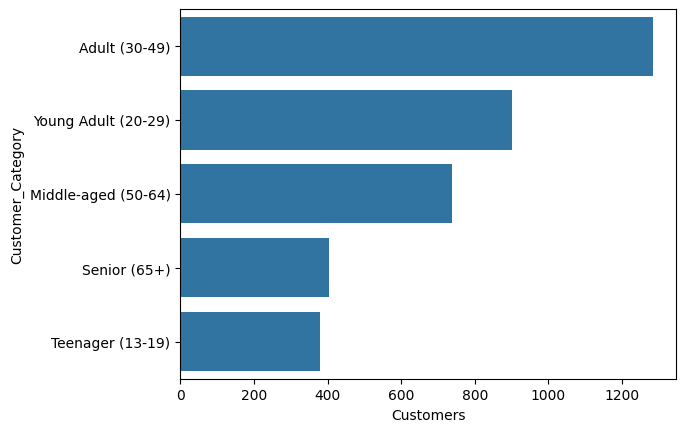

In [26]:
X_test_customer = X_test.groupby("Customer_Category").size().reset_index()
X_test_customer = X_test_customer.rename(columns={0:"Customers"})
sorted_data = X_test_customer.sort_values("Customers", ascending=False)

sns.barplot(sorted_data[:25], y="Customer_Category", x="Customers")

## Visualisasi Data Jumlah Transaksi Berdasarkan Kolom `Season` (Testing Data)

<Axes: xlabel='Customers', ylabel='Season'>

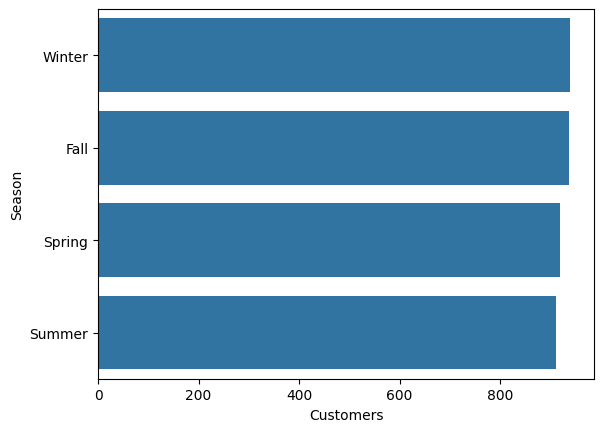

In [27]:
X_test_payment_method = X_test.groupby("Season").size().reset_index()
X_test_payment_method = X_test_payment_method.rename(columns={0:"Customers"})
sorted_data = X_test_payment_method.sort_values("Customers", ascending=False)

sns.barplot(sorted_data, y="Season", x="Customers")

## Visualisasi Data Jumlah Transaksi Berdasarkan Kolom `Promotion` (Testing Data)

<Axes: xlabel='Customers', ylabel='Promotion'>

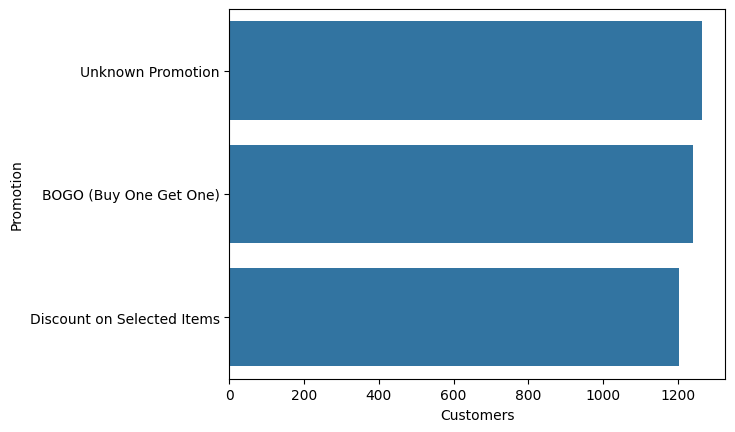

In [28]:
X_test_payment_method = X_test.groupby("Promotion").size().reset_index()
X_test_payment_method = X_test_payment_method.rename(columns={0:"Customers"})
sorted_data = X_test_payment_method.sort_values("Customers", ascending=False)

sns.barplot(sorted_data, y="Promotion", x="Customers")

## Visualisasi Data Jumlah Transaksi Berdasarkan Kolom `TimeClass` (Testing Data)

<Axes: xlabel='Customers', ylabel='TimeClass'>

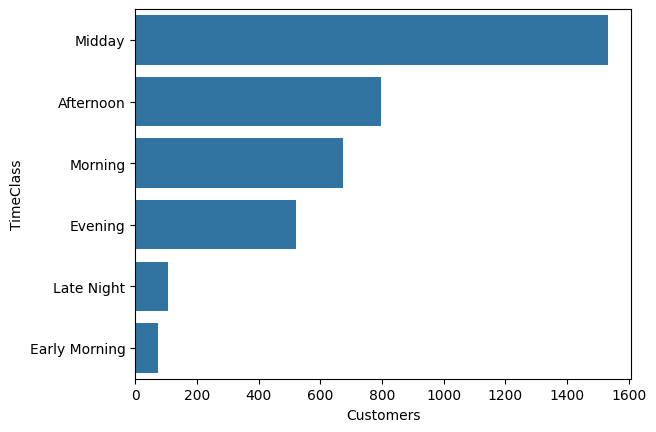

In [29]:
X_test_payment_method = X_test.groupby("TimeClass").size().reset_index()
X_test_payment_method = X_test_payment_method.rename(columns={0:"Customers"})
sorted_data = X_test_payment_method.sort_values("Customers", ascending=False)

sns.barplot(sorted_data, y="TimeClass", x="Customers")

## Pencocokan Kolom Fitur Data Latih dan Kolom Fitur Data Uji

In [30]:
any(X_train.columns == X_test.columns)

True

## Informasi Data Latih Pasca _Feature Engineering_

In [31]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14824 entries, 0 to 14823
Columns: 319 entries, Buy_Air Freshener to Log10_Transformed_Total_Items
dtypes: float64(1), int64(311), object(7)
memory usage: 36.2+ MB


## Informasi Data Uji Pasca Feature Engineering

In [32]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3707 entries, 14824 to 18530
Columns: 319 entries, Buy_Air Freshener to Log10_Transformed_Total_Items
dtypes: float64(1), int64(311), object(7)
memory usage: 9.1+ MB


## Pra-pemrosesan Data Kategorikal Dengan _One Hot Encoding_ (_method_: `skl.preprocessing.OneHotEncoder`)

In [33]:
ohe = skl.preprocessing.OneHotEncoder(sparse_output=False)

X_train_ohe = np.int16(ohe.fit_transform(X_train.select_dtypes(include=object)))
X_test_ohe = np.int16(ohe.transform(X_test.select_dtypes(include=object)))

ohe_features = ohe.get_feature_names_out()

X_train_ohe.shape

(14824, 28)

In [34]:
X_test_ohe.shape

(3707, 28)

In [35]:
len(ohe_features)

28

In [36]:
X_train_ohe

array([[1, 0, 0, ..., 0, 1, 0],
       [0, 0, 1, ..., 0, 1, 0],
       [1, 0, 0, ..., 0, 1, 0],
       ...,
       [1, 0, 0, ..., 0, 1, 0],
       [0, 0, 1, ..., 0, 1, 0],
       [0, 1, 0, ..., 0, 1, 0]], dtype=int16)

In [37]:
X_train.head()

,Buy_Air Freshener,Buy_Allergy Medicine,Buy_Almonds,Buy_Aluminum Foil,Buy_Apples,Buy_Backpack,Buy_Bagels,Buy_Baking Powder,Buy_Baking Soda,Buy_Bananas,...,Buy_Yogurt,Buy_Ziploc Bags,Payment_Method,Customer_Category,Season,Promotion,Member,TimeClass,Loyalty_Level,Log10_Transformed_Total_Items
0,0,0,0,0,0,0,0,0,0,0,...,0,0,Cash,Young Adult (20-29),Spring,Discount on Selected Items,Yes,Early Morning,Regular,0.85
1,0,0,0,0,0,0,0,0,0,0,...,0,0,Debit Card,Teenager (13-19),Spring,BOGO (Buy One Get One),Yes,Early Morning,Regular,0.60
2,0,0,0,0,0,0,0,0,0,0,...,0,0,Cash,Young Adult (20-29),Winter,BOGO (Buy One Get One),Yes,Early Morning,Regular,0.70
3,0,0,0,0,0,0,0,0,0,0,...,0,0,Debit Card,Young Adult (20-29),Winter,Unknown Promotion,Yes,Morning,Regular,0.90
4,0,0,0,0,0,0,0,0,0,0,...,0,0,Mobile Payment,Adult (30-49),Spring,Unknown Promotion,Yes,Morning,Regular,0.85


In [38]:
ohe_features

array(['Payment_Method_Cash', 'Payment_Method_Credit Card',
       'Payment_Method_Debit Card', 'Payment_Method_Mobile Payment',
       'Customer_Category_Adult (30-49)',
       'Customer_Category_Middle-aged (50-64)',
       'Customer_Category_Senior (65+)',
       'Customer_Category_Teenager (13-19)',
       'Customer_Category_Young Adult (20-29)', 'Season_Fall',
       'Season_Spring', 'Season_Summer', 'Season_Winter',
       'Promotion_BOGO (Buy One Get One)',
       'Promotion_Discount on Selected Items',
       'Promotion_Unknown Promotion', 'Member_No', 'Member_Yes',
       'TimeClass_Afternoon', 'TimeClass_Early Morning',
       'TimeClass_Evening', 'TimeClass_Late Night', 'TimeClass_Midday',
       'TimeClass_Morning', 'Loyalty_Level_Gold',
       'Loyalty_Level_Platinum', 'Loyalty_Level_Regular',
       'Loyalty_Level_Silver'], dtype=object)

## Penyisipan Fitur Pasca _One Hot Encoding_

In [39]:
X_train.columns.tolist().index("_".join(ohe_features[0].split("_")[:2]))

311

In [40]:
first_cat = "_".join(ohe_features[0].split("_")[:2])
start_idx = X_train.columns.tolist().index(first_cat)

X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=ohe_features)
X_test_ohe_df = pd.DataFrame(X_test_ohe, columns=ohe_features)

for k in range(start_idx, len(ohe_features) + start_idx):
    single_features = np.int16(X_train_ohe_df[ohe_features[k-start_idx]])
    X_train.insert(start_idx, ohe_features[k-start_idx], single_features)

for k in range(start_idx, len(ohe_features) + start_idx):
    single_features = np.int16(X_test_ohe_df[ohe_features[k-start_idx]])
    X_test.insert(start_idx, ohe_features[k-start_idx], single_features)

display(X_train.info())
display(X_test.info())

<class 'pandas.core.frame.DataFrame'>
Index: 14824 entries, 0 to 14823
Columns: 347 entries, Buy_Air Freshener to Log10_Transformed_Total_Items
dtypes: float64(1), int16(28), int64(311), object(7)
memory usage: 37.0+ MB


None

<class 'pandas.core.frame.DataFrame'>
Index: 3707 entries, 14824 to 18530
Columns: 347 entries, Buy_Air Freshener to Log10_Transformed_Total_Items
dtypes: float64(1), int16(28), int64(311), object(7)
memory usage: 9.2+ MB


None

## Penapisan Fitur Berdasarkan Tipe Data Spesifik (`np.int16`, `np.int32`, dan `np.int64`)

In [41]:
X_train_int = X_train.select_dtypes(include=[np.int16, np.int32, np.int64])
X_test_int = X_test.select_dtypes(include=[np.int16, np.int32, np.int64])

## Deskripsi Fitur Pasca Penapisan Fitur

In [42]:
# sns.boxplot(X_train_int) # kelamaan
X_train_int.describe()

,Buy_Air Freshener,Buy_Allergy Medicine,Buy_Almonds,Buy_Aluminum Foil,Buy_Apples,Buy_Backpack,Buy_Bagels,Buy_Baking Powder,Buy_Baking Soda,Buy_Bananas,...,Season_Fall,Customer_Category_Young Adult (20-29),Customer_Category_Teenager (13-19),Customer_Category_Senior (65+),Customer_Category_Middle-aged (50-64),Customer_Category_Adult (30-49),Payment_Method_Mobile Payment,Payment_Method_Debit Card,Payment_Method_Credit Card,Payment_Method_Cash
count,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,...,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000
mean,0.015853,0.013761,0.015313,0.013087,0.014234,0.016797,0.014166,0.015515,0.014706,0.015785,...,0.250337,0.251956,0.097949,0.100243,0.197450,0.352402,0.251214,0.255262,0.242984,0.250540
std,0.124910,0.116503,0.122799,0.113651,0.118457,0.128515,0.118180,0.123595,0.120377,0.124648,...,0.433222,0.434151,0.297256,0.300334,0.398088,0.477734,0.433726,0.436023,0.428900,0.433338
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Rincian Kolom Fitur Data Latih

In [43]:
X_train.columns

Index(['Buy_Air Freshener', 'Buy_Allergy Medicine', 'Buy_Almonds',
       'Buy_Aluminum Foil', 'Buy_Apples', 'Buy_Backpack', 'Buy_Bagels',
       'Buy_Baking Powder', 'Buy_Baking Soda', 'Buy_Bananas',
       ...
       'Payment_Method_Credit Card', 'Payment_Method_Cash', 'Payment_Method',
       'Customer_Category', 'Season', 'Promotion', 'Member', 'TimeClass',
       'Loyalty_Level', 'Log10_Transformed_Total_Items'],
      dtype='object', length=347)

## Tinjauan Fitur Data Uji `Log10_Transformed_Total_Items`

In [44]:
X_test["Log10_Transformed_Total_Items"]

14824    1.00
14825    0.90
14826    0.90
14827    0.30
14828    0.78
         ... 
18526    0.30
18527    0.70
18528    0.85
18529    0.30
18530    0.70
Name: Log10_Transformed_Total_Items, Length: 3707, dtype: float64

## Pra Pemrosesan Data Latih Multi-Kategori Biner dan Data Uji Multi-Kategori Biner dengan 1-Component Principal Component Analysis (_method_: `skl.decomposition.PCA`)

In [45]:
# std_scaler = skl.preprocessing.StandardScaler()
pca_1 = skl.decomposition.PCA(n_components=1)

# std_numerical_train = std_scaler.fit_transform(X_train_int.values)
# std_numerical_test = std_scaler.transform(X_test_int.values)

# X_train[X_train_int.columns] = std_numerical_train
# X_test[X_test_int.columns] = std_numerical_test

pca_numerical_train = pca_1.fit_transform(X_train_int)
pca_numerical_test = pca_1.transform(X_test_int)

X_train_pca = pd.DataFrame(pca_numerical_train, columns=["Feature_1"])
X_test_pca = pd.DataFrame(pca_numerical_test, columns=["Feature_1"])

X_train_log10 = X_train.Log10_Transformed_Total_Items
X_test_log10 = X_test.Log10_Transformed_Total_Items.reset_index(drop=True)

X_train_concat = (X_train_pca, X_train_log10)
X_test_concat = (X_test_pca, X_test_log10)

X_train_pca_ = pd.concat(X_train_concat, axis=1)
X_test_pca_ = pd.concat(X_test_concat, axis=1)

X_train_pca_.columns = ["Feature_1", "Feature_2"]
X_test_pca_.columns = ["Feature_1", "Feature_2"]

In [46]:
# X_train_pca_abs_transformed = np.abs(X_train_pca_.Feature_1 + 1).values
# X_test_pca_abs_transformed = np.abs(X_test_pca_.Feature_1 + 1).values

# X_train_pca_sign_variables = np.sign(X_train_pca_.Feature_1 + 1)
# X_test_pca_sign_variables = np.sign(X_test_pca_.Feature_1 + 1)

# X_train_transformed = pd.DataFrame(X_train_pca_abs_transformed, columns=["Fe_1"])
# X_train_transformed["Fe_2"] = X_train_pca_.Feature_2

# X_test_transformed = pd.DataFrame(X_test_pca_abs_transformed, columns=["Fe_1"])
# X_test_transformed["Fe_2"] = X_test_pca_.Feature_2

## Visualisasi Data Latih Kombinasi Fitur PCA dan Fitur Logaritmik

<Axes: >

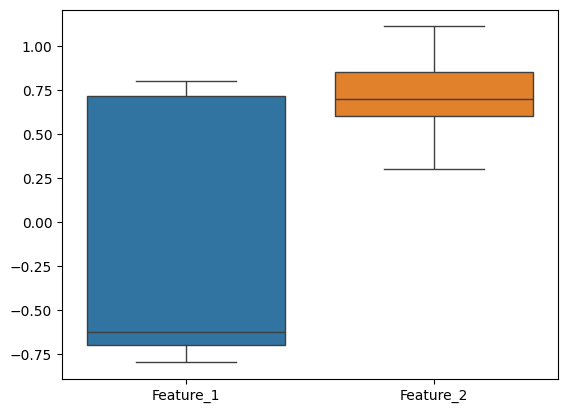

In [47]:
sns.boxplot(X_train_pca_)

## Visualisasi Data Uji Kombinasi Fitur PCA dan Fitur Logaritmik

<Axes: >

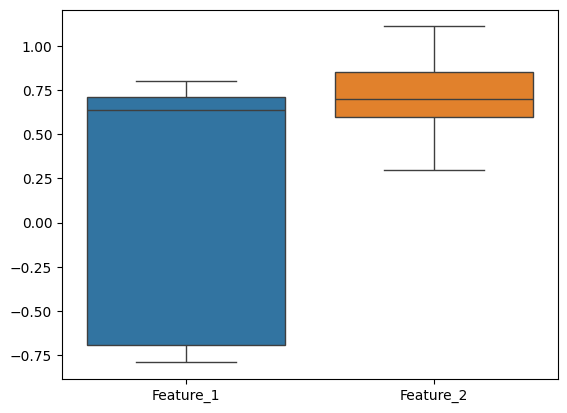

In [48]:
sns.boxplot(X_test_pca_)

## Visualisasi Data Target Latih `Total_Cost`

<Axes: ylabel='Total_Cost'>

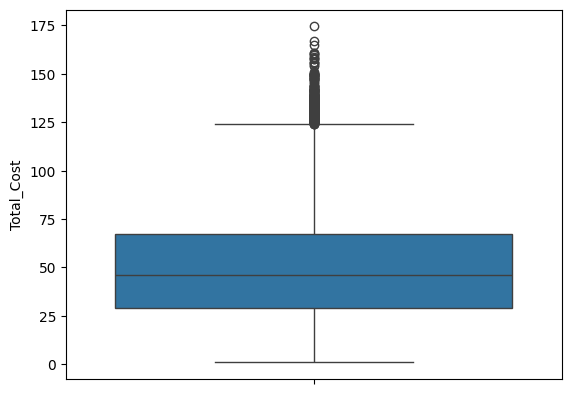

In [49]:
sns.boxplot(y_train)

## Visualisasi Data Target Latih `Total_Cost` Pasca Pembagian dengan Konstanta Angka 10

<Axes: ylabel='Total_Cost'>

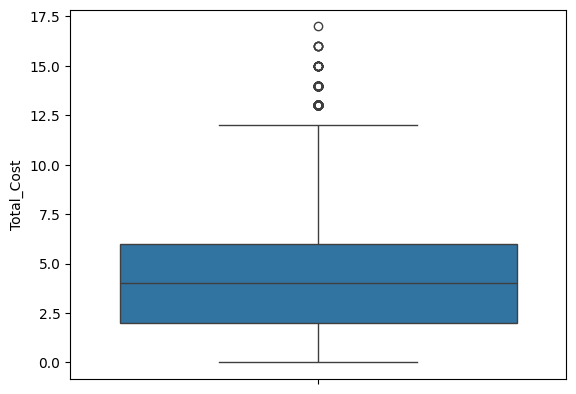

In [50]:
sns.boxplot(y_train // 10)

## Visualisasi Data Target Latih `Total_Cost` Pasca Pembagian dengan Konstanta Angka 10 dan Penjumlahan dengan Angka 1

<Axes: ylabel='Total_Cost'>

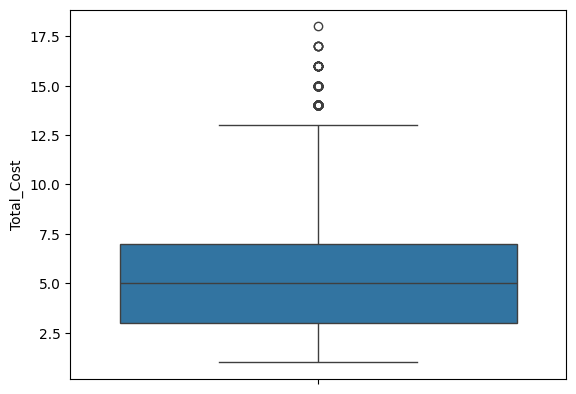

In [51]:
sns.boxplot(y_train // 10 + 1)

## Visualisasi Data Target Latih `Total_Cost` Pasca Pembagian dengan Konstanta Angka 10, Penjumlahan dengan Konstanta Angka 1, dan Transformasi Logaritmik

<Axes: ylabel='Total_Cost'>

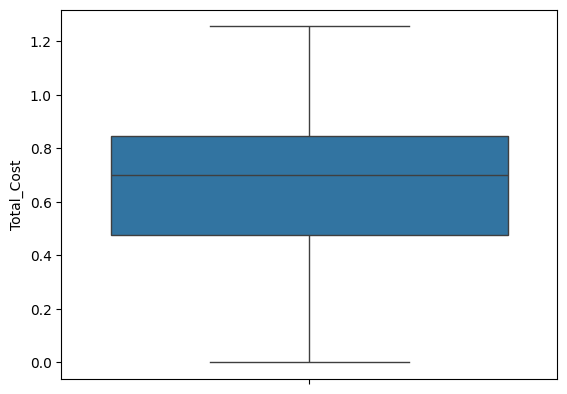

In [52]:
sns.boxplot(np.log10(y_train // 10 + 1))

## _Target Engineering_ khusus Target Latih `Total_Cost`

In [53]:
y_train_log_transformed = np.log10(y_train // 10 + 1)

## Visualisasi Data Target Uji `Total_Cost` Pasca Pembagian dengan Konstanta Angka 10, Penjumlahan dengan Konstanta Angka 1, dan Transformasi Logaritmik

<Axes: ylabel='Total_Cost'>

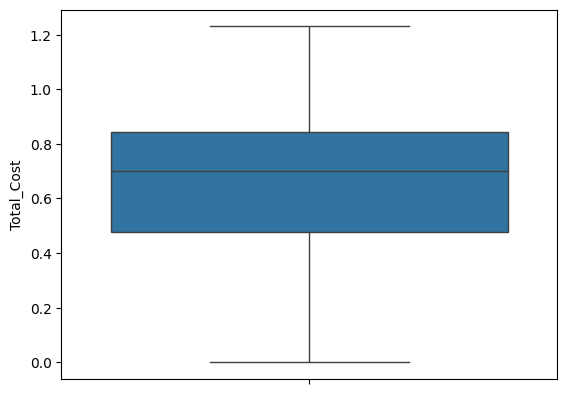

In [54]:
sns.boxplot(np.log10(y_test // 10 + 1))

## _Target Engineering_ khusus Target Uji `Total_Items`

In [55]:
y_test_log_transformed = np.log10(y_test // 10 + 1)

## Inisiasi _5-Fold Cross Validation_

In [56]:
five_fold_cv = skl.model_selection.KFold(n_splits=5)

## Pencarian Model Terbaik dan Model Tercepat dengan Inisiasi Banyak Model (seperti _Decision Tree Regression_ dkk.)

In [57]:
regression_models = {}
regression_models["Decision Tree"] = skl.tree.DecisionTreeRegressor()
regression_models["Random Forest"] = skl.ensemble.RandomForestRegressor()
regression_models["Gradient Boosting"] = skl.ensemble.GradientBoostingRegressor()
regression_models["K-Nearest Neighbors"] = skl.neighbors.KNeighborsRegressor()
regression_models["Linear Regression"] = skl.linear_model.LinearRegression()
regression_models["Multi Layer Perceptron"] = skl.neural_network.MLPRegressor()
regression_models["Support Vector Machine"] = skl.svm.SVR()

best_overall_model = {}
fastest_overall_model = {}

current_mae_ = np.inf
current_time_ = np.inf

for name, model in regression_models.items():
    print(f"Nama Model :: {name}")

    _ = enumerate(five_fold_cv.split(X_train_pca_, y_train_log_transformed))

    mae_folds_ = []

    print("Model sedang pergi ke sekolah untuk belajar selama", end=" ")

    start_time = dttm.now()

    for i, (train_index, test_index) in _:
        # print(f"Fold {i+1}")
        X_train_fold = X_train_pca_.iloc[train_index]
        X_test_fold = X_train_pca_.iloc[test_index]

        X_train_fold = X_train_fold.select_dtypes(exclude=object)
        X_test_fold = X_test_fold.select_dtypes(exclude=object)
        
        y_train_fold = y_train_log_transformed.iloc[train_index]
        y_test_fold = y_train_log_transformed.iloc[test_index]

        model.fit(X_train_fold, y_train_fold)

        y_predict_fold = model.predict(X_test_fold)
        mae_ = skl.metrics.mean_absolute_error(y_test_fold, y_predict_fold)
        
        mae_folds_.append(mae_)

    end_time = dttm.now()

    diffs = (end_time - start_time).total_seconds()

    print(f"{diffs:.2f} detik dengan rerata selisih mutlak rerata", end=" ")
    print(f"final sebesar {np.mean(mae_folds_):.2f}")

    best_overall_model[name] = [np.mean(mae_folds_), model]
    fastest_overall_model[name] = [diffs, model]

    if np.mean(mae_folds_) < current_mae_:
        current_mae_ = np.mean(mae_folds_)

    if diffs < current_time_:
        current_time_ = diffs

best_function = None
fastest_function = None

for k, v in best_overall_model.items():
    if v[0] == current_mae_:
        print(f"Model yang paling bagus prediksinya :: {k}")
        best_function = v[1]
        break

for k, v in fastest_overall_model.items():
    if v[0] == current_time_:
        print(f"Model yang paling cepat prediksinya :: {k}")
        fastest_function = v[1]
        break

joblib.dump(best_function, "/kaggle/working/best_predictor.pkl")
joblib.dump(fastest_function, "/kaggle/working/quick_predictor.pkl")

Nama Model :: Decision Tree
Model sedang pergi ke sekolah untuk belajar selama 0.24 detik dengan rerata selisih mutlak rerata final sebesar 0.12
Nama Model :: Random Forest
Model sedang pergi ke sekolah untuk belajar selama 13.33 detik dengan rerata selisih mutlak rerata final sebesar 0.11
Nama Model :: Gradient Boosting
Model sedang pergi ke sekolah untuk belajar selama 3.99 detik dengan rerata selisih mutlak rerata final sebesar 0.09
Nama Model :: K-Nearest Neighbors
Model sedang pergi ke sekolah untuk belajar selama 0.09 detik dengan rerata selisih mutlak rerata final sebesar 0.10
Nama Model :: Linear Regression
Model sedang pergi ke sekolah untuk belajar selama 0.03 detik dengan rerata selisih mutlak rerata final sebesar 0.09
Nama Model :: Multi Layer Perceptron
Model sedang pergi ke sekolah untuk belajar selama 2.36 detik dengan rerata selisih mutlak rerata final sebesar 0.09
Nama Model :: Support Vector Machine
Model sedang pergi ke sekolah untuk belajar selama 11.43 detik dengan

['/kaggle/working/quick_predictor.pkl']

## Loading dan Uji Prediksi Model Tercepat dan Model Terbaik 

In [58]:
best_model = joblib.load("/kaggle/working/best_predictor.pkl")
quick_model = joblib.load("/kaggle/working/quick_predictor.pkl")

best_prediction = np.round(best_model.predict(X_test_pca_), 2)
quick_prediction = np.round(quick_model.predict(X_test_pca_), 2)

_, X_test, _, _ = tts(
    dataframe.drop("Total_Cost", axis=1), 
    dataframe["Total_Cost"], 
    test_size=0.2, 
    shuffle=False
)

X_test["Total_Cost"] = np.round(10 * (np.pow(10, best_prediction) - 1), 2)

X_test.to_csv("/kaggle/working/best_prediction.csv", index=False)

## Hasil Prediksi dengan Support Vector Machine (Model Terbaik)

In [59]:
X_test.head()

,Transaction_Datetime,Customer_Name,Product,Total_Items,Payment_Method,City,Customer_Category,Season,Promotion,Member,TimeClass,Total_Cost
14824,2023-03-16 13:46:57,Carol Meyers,"['Jam', 'Dish Soap', 'Bath Salts', 'Energy Dri...",9,Cash,Lisaville,Adult (30-49),Winter,Unknown Promotion,Yes,Midday,85.50
14825,2023-03-16 14:07:49,Susan Kirk,"['Colored Pencils', 'Charcoal', 'Baking Soda',...",7,Debit Card,Beltranshire,Young Adult (20-29),Fall,Discount on Selected Items,No,Midday,65.86
14826,2023-03-16 14:48:11,Steven Cummings,"['Band-Aids', 'Bobby Pins', 'Salt', 'Soda', 'S...",7,Mobile Payment,Port Sarahfurt,Adult (30-49),Spring,BOGO (Buy One Get One),No,Midday,65.86
14827,2023-03-16 15:06:47,Debbie Norton,['Dryer Sheets'],1,Mobile Payment,Wellston,Young Adult (20-29),Winter,Unknown Promotion,Yes,Midday,3.49
14828,2023-03-16 16:18:14,Ricky Baker,"['Dried Cranberries', 'Butter', 'Eggs', 'Sanda...",5,Mobile Payment,Michelleview,Senior (65+),Summer,Unknown Promotion,Yes,Afternoon,47.54


## Hasil Prediksi dengan Linear Regression (Model Tercepat)

In [60]:
X_test["Total_Cost"] = np.round(10 * (np.pow(10, quick_prediction) - 1), 2) 

X_test.to_csv("/kaggle/working/quick_prediction.csv", index=False)

X_test.head()

,Transaction_Datetime,Customer_Name,Product,Total_Items,Payment_Method,City,Customer_Category,Season,Promotion,Member,TimeClass,Total_Cost
14824,2023-03-16 13:46:57,Carol Meyers,"['Jam', 'Dish Soap', 'Bath Salts', 'Energy Dri...",9,Cash,Lisaville,Adult (30-49),Winter,Unknown Promotion,Yes,Midday,90.00
14825,2023-03-16 14:07:49,Susan Kirk,"['Colored Pencils', 'Charcoal', 'Baking Soda',...",7,Debit Card,Beltranshire,Young Adult (20-29),Fall,Discount on Selected Items,No,Midday,65.86
14826,2023-03-16 14:48:11,Steven Cummings,"['Band-Aids', 'Bobby Pins', 'Salt', 'Soda', 'S...",7,Mobile Payment,Port Sarahfurt,Adult (30-49),Spring,BOGO (Buy One Get One),No,Midday,65.86
14827,2023-03-16 15:06:47,Debbie Norton,['Dryer Sheets'],1,Mobile Payment,Wellston,Young Adult (20-29),Winter,Unknown Promotion,Yes,Midday,5.14
14828,2023-03-16 16:18:14,Ricky Baker,"['Dried Cranberries', 'Butter', 'Eggs', 'Sanda...",5,Mobile Payment,Michelleview,Senior (65+),Summer,Unknown Promotion,Yes,Afternoon,44.95


## Pekerjaan Yang Akan Saya Lakukan

* Otomasi Pipeline Pra Pemrosesan Data: Imputasi Data -> _Pre-Splitting Feature Engineering_ -> _Data Splitting_ -> _Post-Splitting Feature Engineering_ -> Visualisasi Data -> _Categorical Data Encoding_ -> _Data Dimensionality Reduction_ -> _Target Engineering_
* Permutation Importance Masing-masing Model: _Gradient Boosting_, _Linear Regression_, _Multi-Layer Perceptron_, dan _Support Vector Machine_
* Parallelized Ensemble Regression Antara Model _Gradient Boosting_, _Linear Regression_, _Multi-Layer Perceptron_, dan _Support Vector Machine_
* Sequential Relay Ensemble Regression: _Linear Regression_ -> _Gradient Boosting_ -> _Multi-Layer Perceptron_ -> _Support Vector Machine_
* Dokumentasi Penggunaan Model _Linear Regression_, _Support Vector Machine_, _Stacked Ensemble Regression_, dan _Sequential Relay Ensemble Regression_